# Import libraries

In [1]:
import sys
github_repo_url = "https://github.com/AnnaEls/HAADF-STEM-image-denoising.git"
!git clone {github_repo_url}
sys.path.append('/content/HAADF-STEM-image-denoising')

Cloning into 'HAADF-STEM-image-denoising'...
remote: Enumerating objects: 798, done.
remote: Counting objects: 100% (394/394), done.
remote: Compressing objects: 100% (387/387), done.
remote: Total 798 (delta 202), reused 0 (delta 0), pack-reused 404 (from 2)
Receiving objects: 100% (798/798), 29.56 MiB | 13.08 MiB/s, done.
Resolving deltas: 100% (304/304), done.


In [8]:
!pip install hyperspy
!pip install atomap

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.3/48.3 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 326.5/326.5 kB 31.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 55.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 76.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.5/42.5 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.2/45.2 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 868.9/868.9 kB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 81.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 603.8/603.8 kB 38.0 MB/s eta 0:00:00


In [43]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
import h5py
import tifffile
from Models.hybrid_model import hybrid_model
from Models.UNet import init_unet_kaiming
from Utilities.Utils import prepare_input, convert
from Training.Training import train_hybrid_model

import hyperspy.api as hs
from Analysis.gaussian_detection_atomap import find_atoms

# Settting parameters

In [3]:
#PARAMETERS
#Type of study
STUDY = 'DEFAULT_PARAMETERS'
#Model parameters
WIDTH = 'DEFAULT'
DEPTH = 'DEFAULT'
DEPTH_CNN = 'DEFAULT'
MODEL = hybrid_model()
init_unet_kaiming(MODEL)
#Masking parameters
PATCH_SIZE = 7
MASK_RATIO = 0.2
#Training parameters
LR = 1e-3
NUM_EPOCHS = 300
NUM_RUNS = 1

In [75]:
dataset_path = '/content/HAADF-STEM-image-denoising/Datasets/'
data_file = dataset_path + 'wei_atom_subset_WS2_contrast_variation.h5'

metadata_subset = pd.read_hdf(data_file, key="metadata")

with h5py.File(data_file, "r") as f:
    print("Top-level keys:", list(f.keys()))
    print("Images:", list(f["imgs"].keys()))
    print("Raw:", list(f["raw"].keys()))
    print("Coordinates:", list(f["coords"].keys()))

print("\nMetadata:")
display(metadata_subset)

Top-level keys: ['coords', 'imgs', 'metadata', 'raw']
Images: ['0123', '0124', '0125', '0126', '0127', '0128', '0129', '0130']
Raw: ['0123', '0124', '0125', '0126', '0127', '0128', '0129', '0130']
Coordinates: ['0123', '0124', '0125', '0126', '0127', '0128', '0129', '0130']

Metadata:


,key,Atoms/px,Material_orientation,Spacegroup,Type,contrast,dose_e-/Å²,peakintensity_e-,pixelsize_pm,probe_current_pA,resolution_pm,flybackerror,poisson_dB,randomdrift
123,0123,8.393051,WS2[0001],P63/mmc[194],experimental,0.159,116783.034798,2502.422276,15.46,22.33,98.0,NaN,NaN,NaN
124,0124,8.393051,WS2[0001],P63/mmc[194],experimental,0.133,116783.034798,2365.907658,15.46,22.33,98.0,NaN,NaN,NaN
125,0125,8.393051,WS2[0001],P63/mmc[194],experimental,0.101,116783.034798,2229.216597,15.46,22.33,98.0,NaN,NaN,NaN
126,0126,8.393051,WS2[0001],P63/mmc[194],experimental,0.060,116783.034798,3164.079849,15.46,22.33,98.0,NaN,NaN,NaN
127,0127,8.393051,WS2[0001],P63/mmc[194],experimental,0.048,116783.034798,4146.385107,15.46,22.33,98.0,NaN,NaN,NaN
128,0128,8.393051,WS2[0001],P63/mmc[194],experimental,0.037,116783.034798,4616.112008,15.46,22.33,98.0,NaN,NaN,NaN
129,0129,8.393051,WS2[0001],P63/mmc[194],experimental,0.109,116783.034798,2270.713104,15.46,22.33,98.0,NaN,NaN,NaN
130,0130,8.393051,WS2[0001],P63/mmc[194],experimental,0.087,116783.034798,2179.196693,15.46,22.33,98.0,NaN,NaN,NaN


In [5]:
key = "0128"

with h5py.File(data_file, "r") as f:
    img = f["imgs"][key][:]
    raw = f["raw"][key][:]
    coords = f["coords"][key][:]

print("Image shape:", img.shape)
print("Raw shape:", raw.shape)
print("Coordinates shape:", coords.shape)

Image shape: (256, 256)
Raw shape: (256, 256)
Coordinates shape: (297, 2)


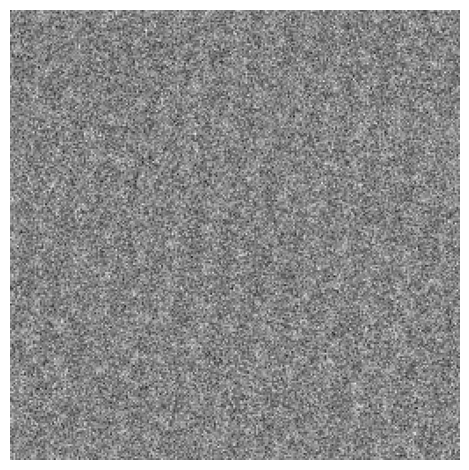

In [6]:
dataset_path_output = "/content/drive/MyDrive/IMAGE DENOISING/Datasets/DATASET_WEI_ATOM_WS2_CONTRAST/"
tifffile.imwrite(dataset_path_output + f'Image_ID_{key}.tif', img)
input_image = prepare_input(dataset_path_output + f'Image_ID_{key}.tif')
output_path_main = dataset_path_output + f'RESULTS/'
output_path_main = output_path_main +  'Image_ID_' + key + '/' + f'{MODEL.__class__.__name__}/' + f'{STUDY}/'
os.makedirs(output_path_main, exist_ok=True)

# Training

In [ ]:
result_path = output_path_main
os.makedirs(result_path, exist_ok=True)
for run in range(NUM_RUNS):
    MODEL = hybrid_model()
    print(f'Starting run {run}')
    output_path = result_path + f'run_{run+3}/'
    os.makedirs(output_path, exist_ok=True)
    train_hybrid_model(MODEL, input_image, output_path, learning_rate=LR, num_iter=NUM_EPOCHS, patch_size=PATCH_SIZE, mask_ratio=MASK_RATIO, show_image=True)

# Analysis

In [49]:
def delete_edge_predictions(edges, shape, predictpos_x, predictpos_y):
  '''
  edges:[left, right, top, bottom] as percentage of the whole image size
  '''
  dellistx = []
  for i, coordx in enumerate (predictpos_x):
     dis = abs(coordx-shape[1])/shape[1]
     if dis> (1-edges[0]) or dis < edges[1]:
       dellistx.append(i)
  dellisty = []
  for i, coordy in enumerate (predictpos_y):
     dis = abs(coordy-shape[0])/shape[0]
     if dis>(1-edges[2])or dis<edges[3]:
       dellisty.append(i)

  dellist = dellistx + dellisty
  dellist = np.unique(np.asarray(dellist))
  try:
    predictpos_x = np.delete(predictpos_x,dellist)
    predictpos_y = np.delete(predictpos_y,dellist)
  except:
    print('You need to re-adjust your edge values for the most accurate measurement\n')

  return(predictpos_x, predictpos_y)

In [53]:
import math
def getScores(predictpos_x, predictpos_y, truthpos_x, truthpos_y, truthnum, tolerance):
  truepoints = []
  pos_se = 0
  tp = 0

  for i in range(predictpos_x.size):
    for j in range(truthpos_x.size):
      square_error = (predictpos_x[i] - truthpos_x[j])**2 + (predictpos_y[i] - truthpos_y[j])**2
      if square_error < tolerance:
        truepoints.append((predictpos_y[i],predictpos_x[i]))
        pos_se = pos_se + square_error
        tp = tp + 1
  try:
    rmse = math.sqrt(pos_se / tp)
  except:
    rmse = None
    recall = 0
    precision = 0
    print('No TP. ')

  recall = tp / truthnum
  if predictpos_x.shape[0]!= 0:
    precision = tp / predictpos_x.size
  else: precision = 0

  print('position deviation = ', rmse, 'px, recall = ', tp, '/', truthnum, ' = ', recall, ', precision = ', tp, '/', predictpos_x.size, ' = ', precision)
  scores = (rmse, recall, precision)
  return scores

Image ID: 0123


Gaussian fitting: 100%|██████████| 290/290 [00:04<00:00, 71.56it/s]


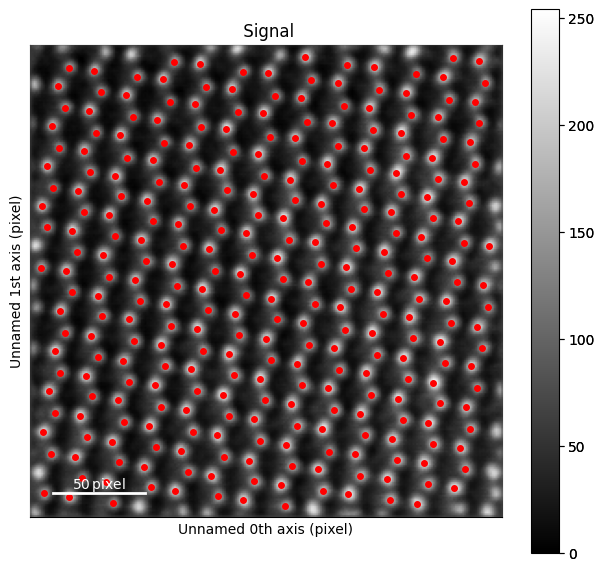

Image ID: 0124


Gaussian fitting: 100%|██████████| 285/285 [00:04<00:00, 69.03it/s]


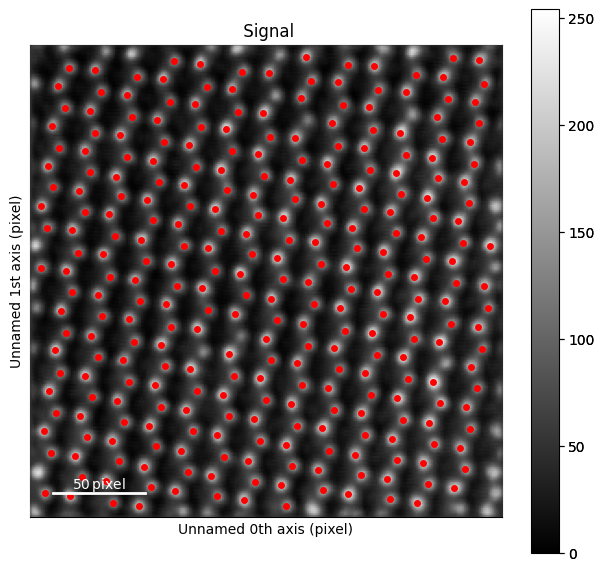

Image ID: 0125


Gaussian fitting: 100%|██████████| 286/286 [00:04<00:00, 67.73it/s]


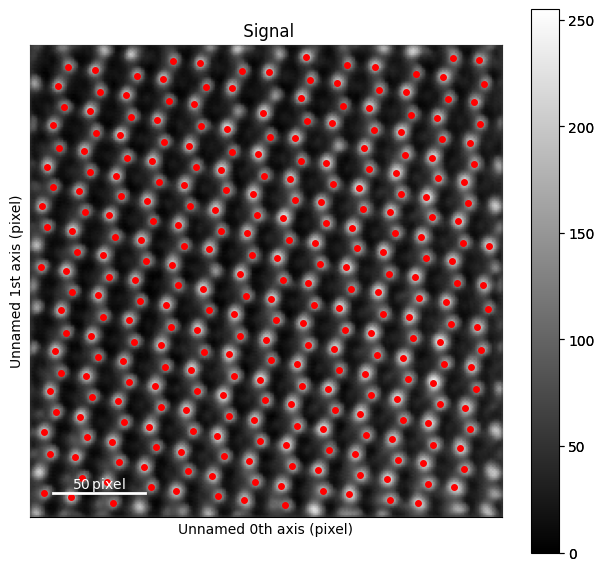

Image ID: 0126


Gaussian fitting: 100%|██████████| 288/288 [00:04<00:00, 63.22it/s]


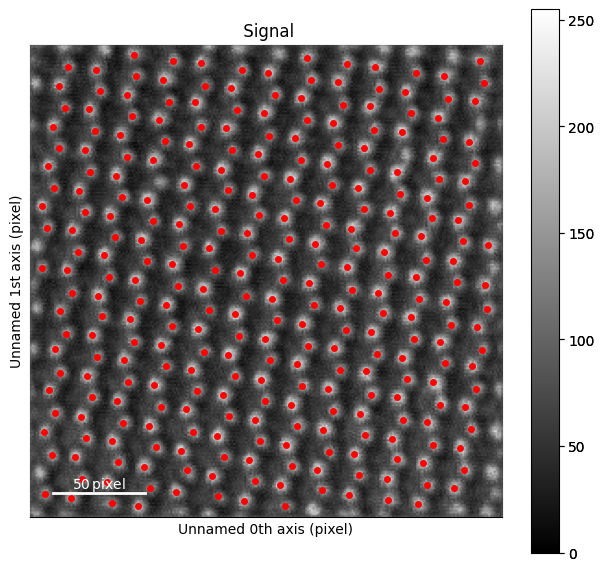

Image ID: 0127


Gaussian fitting: 100%|██████████| 266/266 [00:03<00:00, 70.94it/s]


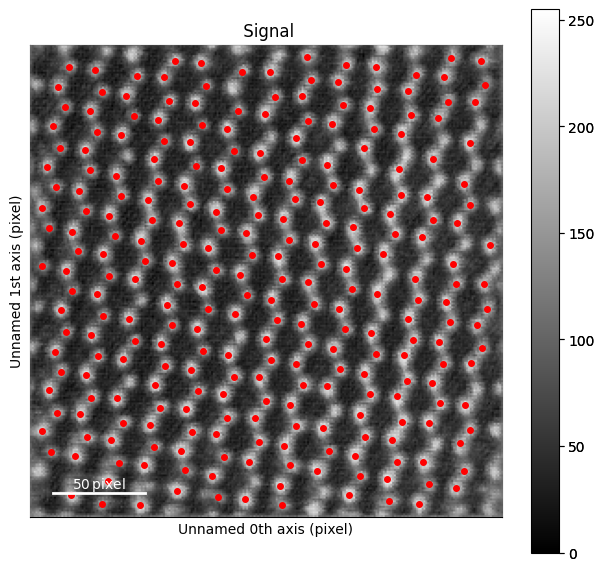

Image ID: 0128


Gaussian fitting: 100%|██████████| 289/289 [00:04<00:00, 67.44it/s]


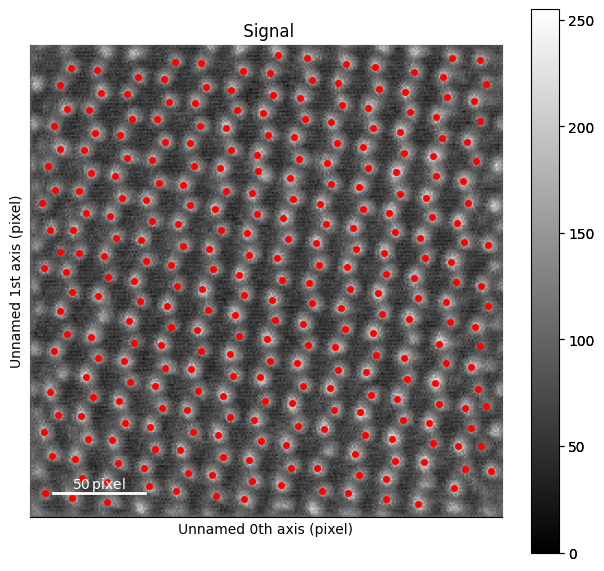

Image ID: 0129


Gaussian fitting: 100%|██████████| 286/286 [00:04<00:00, 69.01it/s]


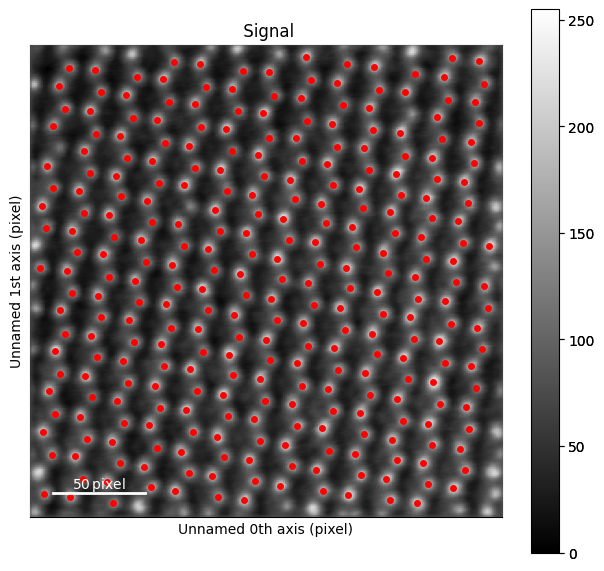

Image ID: 0130


Gaussian fitting: 100%|██████████| 291/291 [00:05<00:00, 57.48it/s]


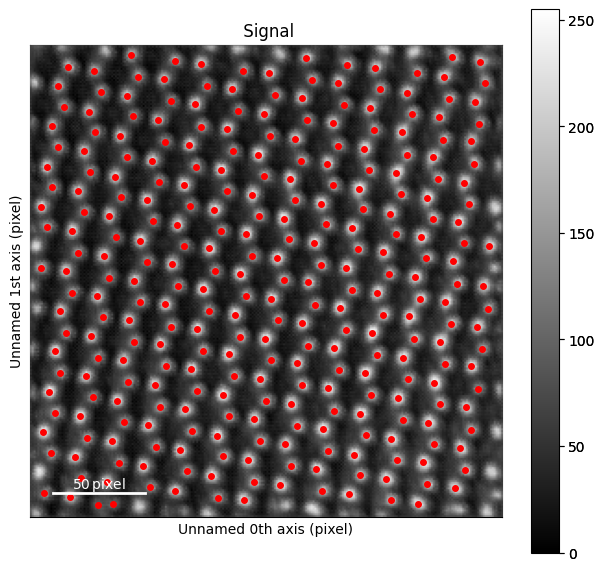

In [39]:
keys = ["0123", "0124", "0125", "0126", "0127", "0128", "0129", "0130"]
for key in keys:
    print("Image ID:" , key)
    output_path = f"/content/drive/MyDrive/IMAGE DENOISING/Datasets/DATASET_WEI_ATOM_WS2_CONTRAST/RESULTS/Image_ID_" + key + "/hybrid_model/DEFAULT_PARAMETERS/run_3/"
    image_path = output_path + "AFNO_0300.tif"
    s = hs.load(image_path)
    gaussians = find_atoms(s, separation = 6, plot = True)
    plt.show()
    atom_data = []
    for atom in gaussians.atom_list:
      atom_data.append({
        'x': atom.pixel_x,
        'y': atom.pixel_y,
        'sx': atom.sigma_x,
        'sy': atom.sigma_y,
        'r': atom.rotation,
        'e': atom.ellipticity,
        'amplitude_gaussian': atom.amplitude_gaussian
       })
    df_gaussians = pd.DataFrame(atom_data)
    df_gaussians.to_csv(output_path + 'gaussians_image_ID_' + key + '_AFNO_0300.csv', index=False)

Image ID: 0123


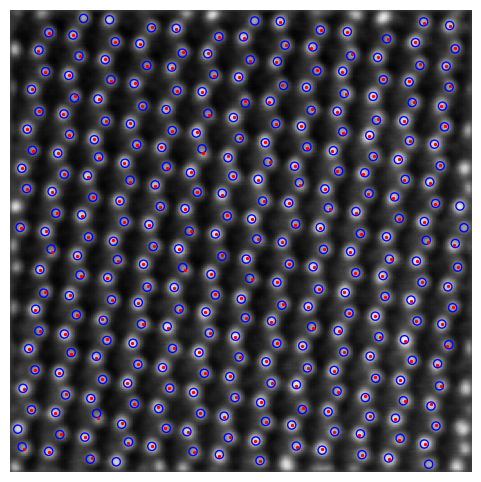

position deviation =  0.6290955868218564 px, recall =  289 / 297  =  0.9730639730639731 , precision =  289 / 289  =  1.0
Image ID: 0124


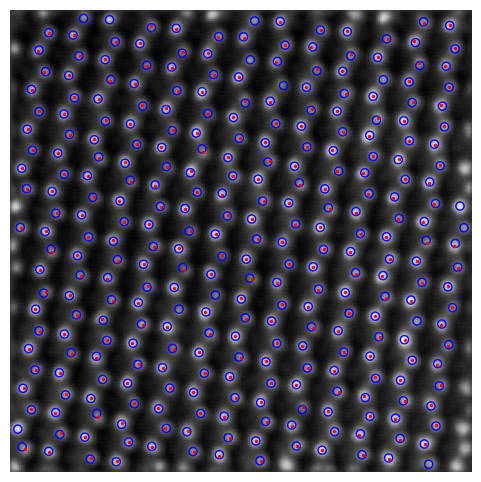

position deviation =  0.6403639468416336 px, recall =  284 / 297  =  0.9562289562289562 , precision =  284 / 284  =  1.0
Image ID: 0125
You need to re-adjust your edge values for the most accurate measurement



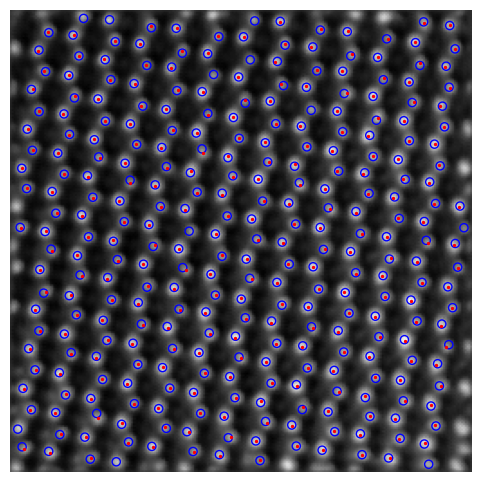

position deviation =  0.7547701149596929 px, recall =  286 / 297  =  0.9629629629629629 , precision =  286 / 286  =  1.0
Image ID: 0126


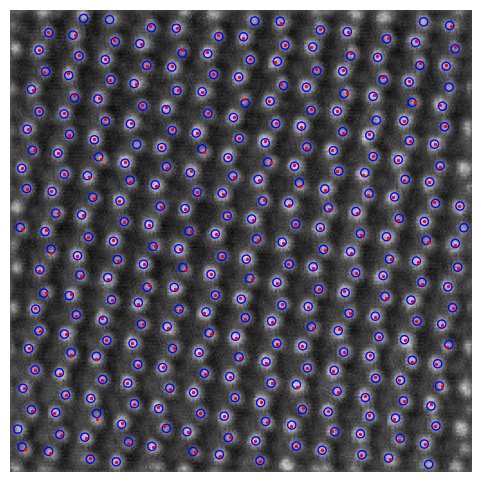

position deviation =  0.8669495765956727 px, recall =  287 / 297  =  0.9663299663299664 , precision =  287 / 287  =  1.0
Image ID: 0127


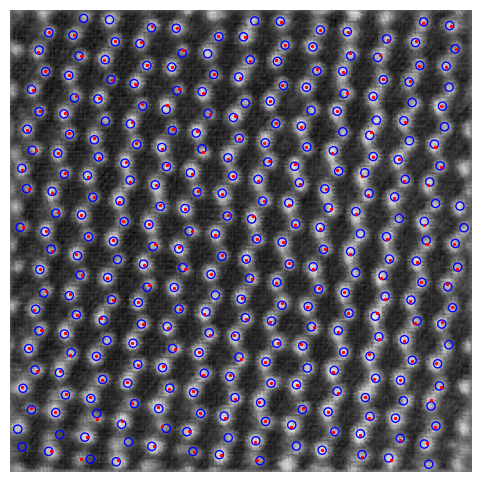

position deviation =  1.0225895557120102 px, recall =  263 / 297  =  0.8855218855218855 , precision =  263 / 265  =  0.9924528301886792
Image ID: 0128


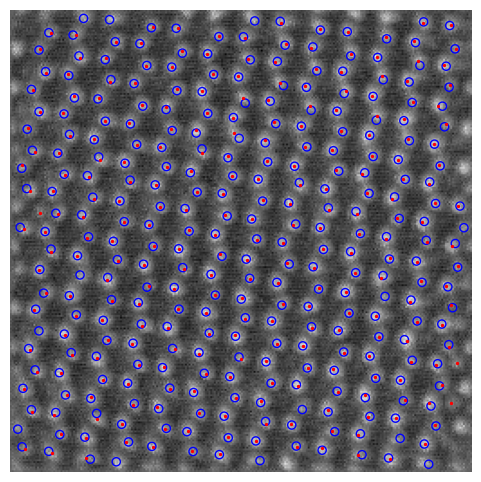

position deviation =  1.077709055571443 px, recall =  282 / 297  =  0.9494949494949495 , precision =  282 / 287  =  0.9825783972125436
Image ID: 0129


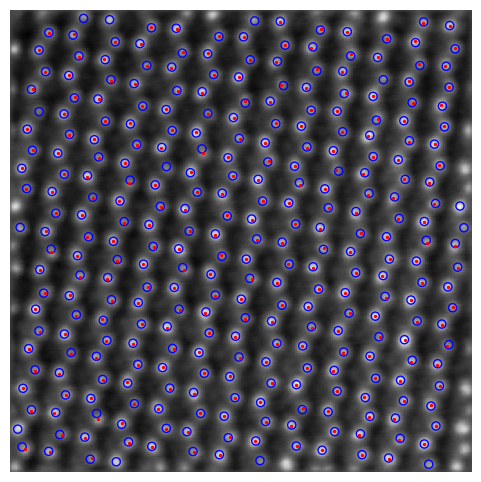

position deviation =  0.6349985818537119 px, recall =  283 / 297  =  0.9528619528619529 , precision =  283 / 284  =  0.9964788732394366
Image ID: 0130


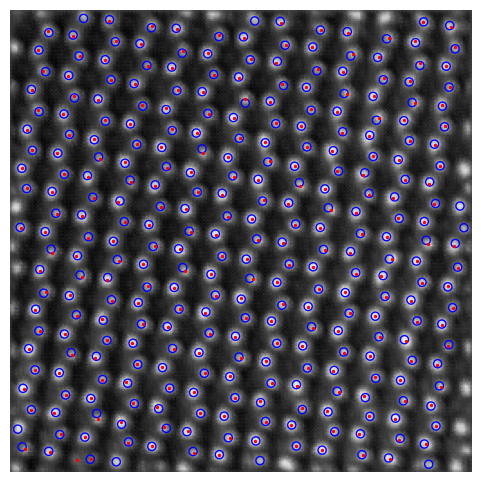

position deviation =  0.835345320101169 px, recall =  289 / 297  =  0.9730639730639731 , precision =  289 / 290  =  0.996551724137931


In [101]:
keys = ["0123", "0124", "0125", "0126", "0127", "0128", "0129", "0130"]
rows = []
for key in keys:
    print("Image ID:" , key)
    output_path = f"/content/drive/MyDrive/IMAGE DENOISING/Datasets/DATASET_WEI_ATOM_WS2_CONTRAST/RESULTS/Image_ID_" + key + "/hybrid_model/DEFAULT_PARAMETERS/run_3/"
    image_path = output_path + "AFNO_0300.tif"
    image = tifffile.imread(image_path)
    gaussians = pd.read_csv(output_path + 'gaussians_image_ID_' + key + '_AFNO_0300.csv')
    with h5py.File(data_file, "r") as f:
        coords = f["coords"][key][:]
    truthpos_x,truthpos_y = np.transpose(coords)
    truthnum = truthpos_y.shape[0]
    predictpos_x, predictpos_y = gaussians['x'], gaussians['y']
    predictpos_x_refined, predictpos_y_refined = delete_edge_predictions([0.02, 0.03, 0.02, 0.02], image.shape, predictpos_x, predictpos_y)
    fig = plt.figure(figsize=(6,6))
    plt.imshow(image, cmap = 'gray')
    plt.scatter(truthpos_x,truthpos_y,s = 35, facecolors='none', edgecolors = 'b')
    plt.scatter(predictpos_x_refined,predictpos_y_refined,s = 2, c = 'red')
    plt.axis('off')
    plt.show()
    angstrom_per_px = metadata_subset.loc[metadata_subset["key"] == key, "pixelsize_pm"].values[0]/100
    tolerance = np.round((0.5/angstrom_per_px)**2, 1)
    rmse, r, p = getScores(predictpos_x_refined, predictpos_y_refined, truthpos_x, truthpos_y, truthnum, tolerance)
    contrast = metadata_subset.loc[metadata_subset["key"] == key, "contrast"].values[0]
    rows.append({"image_ID": key, "contrast": contrast, "rmse": rmse, "recall" : r, "precision": p})

In [104]:
df_results = pd.DataFrame(rows)
display(df_results)
output_path_results = "/content/drive/MyDrive/IMAGE DENOISING/Datasets/DATASET_WEI_ATOM_WS2_CONTRAST/"
df_results.to_csv(output_path_results + "gaussians_positions_evaluation_hybrid_model.csv", index=False)

,image_ID,contrast,rmse,recall,precision
0,0123,0.159,0.629096,0.973064,1.000000
1,0124,0.133,0.640364,0.956229,1.000000
2,0125,0.101,0.754770,0.962963,1.000000
3,0126,0.060,0.866950,0.966330,1.000000
4,0127,0.048,1.022590,0.885522,0.992453
5,0128,0.037,1.077709,0.949495,0.982578
6,0129,0.109,0.634999,0.952862,0.996479
7,0130,0.087,0.835345,0.973064,0.996552
